In [1]:
!pip install imbalanced-learn evaluate transformers[torch] accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 20.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 31.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.7 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import library yang dibutuhkan
import pandas as pd
import numpy as np
import os
import torch
import string
import re
import evaluate
from torch.optim import AdamW
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler, Trainer, TrainingArguments

from datasets import Dataset, concatenate_datasets, DatasetDict, load_metric

from sklearn.metrics import ConfusionMatrixDisplay

In [5]:
# load dataset

df_cnn_path = '/content/drive/My Drive/Dataset Skripsi/dataset_cnn_summarized.xlsx'
df_kompas_path = '/content/drive/My Drive/Dataset Skripsi/dataset_kompas_summarized.xlsx'
df_tempo_path = '/content/drive/My Drive/Dataset Skripsi/dataset_tempo_summarized.xlsx'
df_tbh_path = '/content/drive/My Drive/Dataset Skripsi/dataset_turnbackhoax_summarized.xlsx'

df_cnn = pd.read_excel(df_cnn_path)
df_kompas = pd.read_excel(df_kompas_path)
df_tempo = pd.read_excel(df_tempo_path)
df_tbh = pd.read_excel(df_tbh_path)

In [6]:
# Filter baris yang kolom 'cleaned' tidak NaN untuk setiap dataframe
df_cnn = df_cnn[df_cnn['cleaned'].isna() == False]
df_kompas = df_kompas[df_kompas['cleaned'].isna() == False]
df_tempo = df_tempo[df_tempo['cleaned'].isna() == False]
df_tbh = df_tbh[df_tbh['cleaned'].isna() == False]

In [7]:
# Mengubah kolom 'cleaned' menjadi tipe data string untuk setiap dataframe
df_cnn['cleaned'] = df_cnn['cleaned'].astype(str)
df_kompas['cleaned'] = df_kompas['cleaned'].astype(str)
df_tempo['cleaned'] = df_tempo['cleaned'].astype(str)
df_tbh['cleaned'] = df_tbh['cleaned'].astype(str)

In [8]:
# Fungsi untuk mengubah spasi menjadi tanda baca
def space_to_punct(text):
  # Loop untuk mengganti setiap tanda baca dengan spasi di sekelilingnya
    for punct in string.punctuation:
        text = text.replace(punct, f' {punct} ')

    text = re.sub(' +', ' ', text)  # Mengganti spasi ganda dengan spasi tunggal
    return text

# Mengaplikasikan fungsi space_to_punct pada kolom 'cleaned' untuk setiap dataframe
df_cnn['cleaned'] = df_cnn['cleaned'].map(lambda x: space_to_punct(x))
df_kompas['cleaned'] = df_kompas['cleaned'].map(lambda x: space_to_punct(x))
df_tempo['cleaned'] = df_tempo['cleaned'].map(lambda x: space_to_punct(x))
df_tbh['cleaned'] = df_tbh['cleaned'].map(lambda x: space_to_punct(x))

In [9]:
# Memilih kolom 'cleaned' dari setiap dataframe dan menambahkan kolom 'labels'
df_cnn_cleaned = df_cnn[['cleaned']]
df_cnn_cleaned['labels'] = 0
df_kompas_cleaned = df_kompas[['cleaned']]
df_kompas_cleaned['labels'] = 0
df_tempo_cleaned = df_tempo[['cleaned']]
df_tempo_cleaned['labels'] = 0
df_tbh_cleaned = df_tbh[['cleaned']]
df_tbh_cleaned['labels'] = 1

<ipython-input-9-c5a893b9287b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cnn_cleaned['labels'] = 0
<ipython-input-9-c5a893b9287b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kompas_cleaned['labels'] = 0
<ipython-input-9-c5a893b9287b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#

In [10]:
df_tbh_cleaned.head(2)

,cleaned,labels
0,BISA DILIHAT SI ONTA YAMAN NGGAK PEDULI ITU AP...,1
1,ini bener gasih ? ? Ya Allah gimna keadaan pa ...,1


In [11]:
df = pd.concat([df_cnn_cleaned, df_kompas_cleaned, df_tempo_cleaned, df_tbh_cleaned], ignore_index=True) #menggabungkan dataset
df

,cleaned,labels
0,Anies di Milad BKMT : Pengajian Menghasilkan I...,0
1,Edy Soal Pilgub Sumut : Kalau yang Maju Abal -...,0
2,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,0
3,Gede Pasek Doakan AHY Jadi Capres atau Cawapre...,0
4,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,0
...,...,...
27442,Raja Salman dari arab saudi membawa orang - or...,1
27443,"hehe , selalu bisa tersenyum melihat tingkah l...",1
27444,Pak Jokowi itu menjadi walikota periode pertam...,1
27445,"Hari ini , Rabu ( 23 / 09 / 2015 ) , nilai tuk...",1


In [ ]:
df['length_text'] = df['cleaned'].apply(len) #menambahkan kolom length_text

,cleaned,labels,length_text,words_per_sentence,total_words_per_sentence
0,Anies di Milad BKMT : Pengajian Menghasilkan I...,0,1986,"[45, 15, 16, 18, 13, 35, 16, 35, 33, 22, 54, 2...",335
1,Edy Soal Pilgub Sumut : Kalau yang Maju Abal -...,0,1944,"[30, 17, 35, 10, 15, 21, 6, 10, 11, 8, 12, 10,...",350
2,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,0,1301,"[36, 33, 37, 14, 16, 27, 19, 13, 23, 5]",223
3,Gede Pasek Doakan AHY Jadi Capres atau Cawapre...,0,1324,"[36, 15, 10, 46, 14, 15, 11, 9, 7, 11, 24, 10,...",223
4,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,0,1478,"[37, 23, 38, 11, 10, 17, 16, 13, 19, 29, 9, 13...",251
...,...,...,...,...,...
27442,Raja Salman dari arab saudi membawa orang - or...,1,155,[28],28
27443,"hehe , selalu bisa tersenyum melihat tingkah l...",1,138,"[11, 10]",21
27444,Pak Jokowi itu menjadi walikota periode pertam...,1,636,"[20, 30, 17, 3, 7, 13, 6, 20]",116
27445,"Hari ini , Rabu ( 23 / 09 / 2015 ) , nilai tuk...",1,115,"[22, 5]",27


In [ ]:
df.describe()

,labels,length_text,total_words_per_sentence
count,27447.000000,27447.000000,27447.000000
mean,0.236893,1559.517980,260.888221
std,0.425184,1310.868854,219.549719
min,0.000000,3.000000,1.000000
25%,0.000000,521.000000,87.000000
50%,0.000000,1521.000000,254.000000
75%,0.000000,2148.000000,359.000000
max,1.000000,34397.000000,6073.000000


In [12]:
from imblearn.under_sampling import RandomUnderSampler

X = df[['cleaned']]
y = df['labels']

rus = RandomUnderSampler(random_state=1, replacement=True) # Menerapkan RandomUnderSampler
X_new, y_new = rus.fit_resample(X,y)

In [13]:
X_new

,cleaned
235,PSI Sebut Banding Pemecatan Viani Limardi Dito...
12172,Jumlah Bakal Paslon Tunggal pada Pilkada Naik ...
5192,DPR - Pemerintah - KPU Sepakat Honor Petugas T...
17289,Presiden Jokowi Bahas Perang Rusia Ukraina den...
10955,Koalisi PKB - PKS Dinilai Baik Buat Redam Poli...
...,...
27442,Raja Salman dari arab saudi membawa orang - or...
27443,"hehe , selalu bisa tersenyum melihat tingkah l..."
27444,Pak Jokowi itu menjadi walikota periode pertam...
27445,"Hari ini , Rabu ( 23 / 09 / 2015 ) , nilai tuk..."


In [14]:
y_new

235      0
12172    0
5192     0
17289    0
10955    0
        ..
27442    1
27443    1
27444    1
27445    1
27446    1
Name: labels, Length: 13004, dtype: int64

In [15]:
from collections import Counter

# Menghitung jumlah kemunculan setiap nilai dalam y_new
counter = Counter(y_new)
print(counter)

Counter({0: 6502, 1: 6502})


In [16]:
df_new = X_new
df_new['labels'] = y_new

In [17]:
df_new

,cleaned,labels
235,PSI Sebut Banding Pemecatan Viani Limardi Dito...,0
12172,Jumlah Bakal Paslon Tunggal pada Pilkada Naik ...,0
5192,DPR - Pemerintah - KPU Sepakat Honor Petugas T...,0
17289,Presiden Jokowi Bahas Perang Rusia Ukraina den...,0
10955,Koalisi PKB - PKS Dinilai Baik Buat Redam Poli...,0
...,...,...
27442,Raja Salman dari arab saudi membawa orang - or...,1
27443,"hehe , selalu bisa tersenyum melihat tingkah l...",1
27444,Pak Jokowi itu menjadi walikota periode pertam...,1
27445,"Hari ini , Rabu ( 23 / 09 / 2015 ) , nilai tuk...",1


In [18]:
df_true = df_new[df_new['labels'] == 0]

df_true

,cleaned,labels
235,PSI Sebut Banding Pemecatan Viani Limardi Dito...,0
12172,Jumlah Bakal Paslon Tunggal pada Pilkada Naik ...,0
5192,DPR - Pemerintah - KPU Sepakat Honor Petugas T...,0
17289,Presiden Jokowi Bahas Perang Rusia Ukraina den...,0
10955,Koalisi PKB - PKS Dinilai Baik Buat Redam Poli...,0
...,...,...
11776,Dugaan Politik Uang Muncul Jelang Musda Golkar...,0
14617,Top Nasional : Putra Try Sutrisno Jadi Pangdam...,0
14229,Apa Guna Partai Politik ? JENGAH dengan polah ...,0
9066,"Elektabilitas Naik , Demokrat Klaim Rakyat Tak...",0


In [19]:
df_false = df_new[df_new['labels'] == 1]

df_false

,cleaned,labels
20945,BISA DILIHAT SI ONTA YAMAN NGGAK PEDULI ITU AP...,1
20946,ini bener gasih ? ? Ya Allah gimna keadaan pa ...,1
20947,Nenek lampir pemimpin partai banteng bercula s...,1
20948,gerombolan kulup banyak menyusup ke ormas2 isl...,1
20949,M g w ti Di Panggil B4waslu : exclamation : Bv...,1
...,...,...
27442,Raja Salman dari arab saudi membawa orang - or...,1
27443,"hehe , selalu bisa tersenyum melihat tingkah l...",1
27444,Pak Jokowi itu menjadi walikota periode pertam...,1
27445,"Hari ini , Rabu ( 23 / 09 / 2015 ) , nilai tuk...",1


In [20]:
dataset_train_test_true = Dataset.from_pandas(df_true).train_test_split(seed=1, test_size=0.2) # Melakukan train-test split untuk dataset_true

dataset_train_test_false = Dataset.from_pandas(df_false).train_test_split(seed=1, test_size=0.2) # Melakukan train-test split untuk dataset_false

In [21]:
dataset_test_eval_true = dataset_train_test_true['test'].train_test_split(seed=1, test_size=0.5) # Melakukan train-test split untuk dataset_test_eval_true

dataset_test_eval_false = dataset_train_test_false['test'].train_test_split(seed=1, test_size=0.5) # Melakukan train-test split untuk dataset_test_eval_false

In [22]:
ds_train = concatenate_datasets([
    dataset_train_test_true['train'],
    dataset_train_test_false['train']
]) # Menggabungkan dataset_train_test_true dan dataset_train_test_false menjadi dataset_train
ds_eval = concatenate_datasets([
    dataset_test_eval_true['train'],
    dataset_test_eval_false['train']
]) # Menggabungkan dataset_test_eval_true dan dataset_test_eval_false menjadi dataset_eval
ds_test = concatenate_datasets([
    dataset_test_eval_true['test'],
    dataset_test_eval_false['test']
])  # Menggabungkan dataset_test_eval_true dan dataset_test_eval_false menjadi dataset_test

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [24]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1") # Memuat tokenizer dari model Indobert-base-p1
model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=5) # Memuat model Indobert-base-p1

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
def tokenize_dataset(data):
    return tokenizer(data["cleaned"], padding=True, truncation=True, max_length=512)

ds_train_ = ds_train.map(tokenize_dataset) # Memproses tokenisasi pada dataset pelatihan
ds_eval_ = ds_eval.map(tokenize_dataset) # Memproses tokenisasi pada dataset evaluasi
ds_test_ = ds_test.map(tokenize_dataset) # Memproses tokenisasi pada dataset uji

Map:   0%|          | 0/10402 [00:00<?, ? examples/s]

Map:   0%|          | 0/1300 [00:00<?, ? examples/s]

Map:   0%|          | 0/1302 [00:00<?, ? examples/s]

In [26]:
# Menghapus kolom "cleaned" dari dataset yang sudah ditokenisasi untuk ds_train_, ds_eval_, dan ds_test_
ds_train_tokenized = ds_train_.remove_columns(["cleaned"])
ds_eval_tokenized = ds_eval_.remove_columns(["cleaned"])
ds_test_tokenized = ds_test_.remove_columns(["cleaned"])

# Menggabungkan dataset-dataframe menjadi sebuah DatasetDict
dataset_full = DatasetDict({
    'train': ds_train_tokenized,
    'test': ds_eval_tokenized,
    'eval': ds_test_tokenized})

dataset_full

DatasetDict({
    train: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10402
    })
    test: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1300
    })
    eval: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1302
    })
})

In [27]:
batch_size = 16

args = TrainingArguments(
    output_dir=f"IndoBERT-NotSummarized-HoaxDetection",
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=5,
    weight_decay=0.01,
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [28]:
metric = evaluate.load('accuracy', trust_remote_code=True)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

In [29]:
model = model.to(device)

trainer = Trainer(
    model,
    args,
    train_dataset=dataset_full["train"],
    eval_dataset=dataset_full["eval"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
os.environ["WANDB_DISABLED"] = "true"
trainer.evaluate(eval_dataset=dataset_full["test"])

{'eval_loss': 1.4869295358657837,
 'eval_accuracy': 0.37384615384615383,
 'eval_runtime': 34.6974,
 'eval_samples_per_second': 37.467,
 'eval_steps_per_second': 2.363}

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.090600,0.031828,0.991551
2,0.016900,0.019924,0.996928
3,0.008700,0.043077,0.993088
4,0.000200,0.039708,0.993856
5,0.000300,0.025947,0.996160


TrainOutput(global_step=3255, training_loss=0.018357332841923802, metrics={'train_runtime': 5126.1581, 'train_samples_per_second': 10.146, 'train_steps_per_second': 0.635, 'total_flos': 1.3540950718343988e+16, 'train_loss': 0.018357332841923802, 'epoch': 5.0})

In [ ]:
trainer.save_model("./trained_model")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("trained_model")
model = AutoModelForSequenceClassification.from_pretrained("trained_model")

In [ ]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
pred_output = trainer.predict(test_dataset=dataset_full["test"])

In [ ]:
dataset_full["test"]

Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1300
})

In [ ]:
pred_output.metrics

{'test_loss': 1.8743122816085815,
 'test_accuracy': 0.12076923076923077,
 'test_runtime': 36.7315,
 'test_samples_per_second': 35.392,
 'test_steps_per_second': 2.232}

In [ ]:
pred_label = np.argmax(pred_output.predictions, axis=1)
gt_label = dataset_full["test"]['labels']

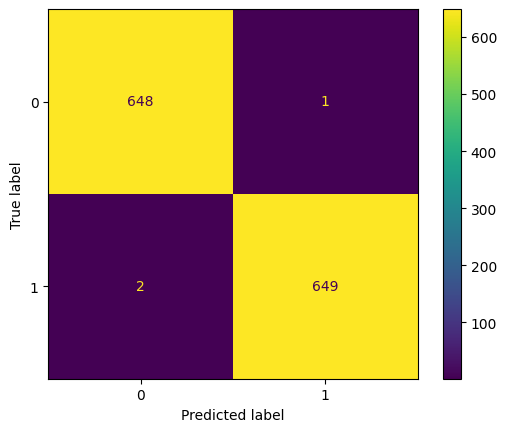

In [ ]:
ConfusionMatrixDisplay.from_predictions(pred_label, gt_label);

In [ ]:
# take it from tokenized data instead of input
test_data = tokenizer.batch_decode(dataset_full["test"]['input_ids'], skip_special_tokens=True)

# create gt and prediction comparation
pred_compare = []
for i, news in enumerate(test_data):
    pred_compare.append([news, gt_label[i], pred_label[i]])

# turn it to dataframe for easy processing
df_pred_compare = pd.DataFrame(pred_compare)
df_pred_compare = df_pred_compare.rename(columns={0:'news', 1:'labels', 2:'prediction'})
df_pred_compare.to_csv('predictions.csv')
df_pred_compare

,news,labels,prediction
0,formappi kritik kader pdip di dpr bentuk dewan...,0,0
1,lukman hakim ppp tanya solusi jika kpu'nyerah'...,0,0
2,"lama ngobrol di gedung dprd dki, pengamat poli...",0,0
3,bawaslu persilakan warga lapor soal isu intimi...,0,0
4,perludem usulkan pembiayaan partai politik ole...,0,0
...,...,...,...
1295,farel prayoga meninggal dunia sakit? kabar ter...,1,1
1296,info oksigen,1,1
1297,"mentri luar negeri ibu retno marsudi, memberit...",1,1
1298,coba perhatikan tanda tangan yg tercantum dala...,1,1


In [ ]:
df_wrong_pred = df_pred_compare[df_pred_compare['labels'] != df_pred_compare['prediction']]
df_pred_compare.to_csv('predictions-wrong.csv')

def label_to_str(label_int):
    label = 'Hoax' if label_int == 1 else 'Fakta'
    return f'{label} [{label_int}]'

for i, row in enumerate(df_wrong_pred.values):
    print(f'{i+1} | {row[0]}')

    print(f'>> Ground Truth label: {label_to_str(row[1])}, but predicted as: {label_to_str(row[2])}')
    print()

1 | [ hoaks ] video kedatangan anies baswedan disambut meriah di bali di media sosial muncul video yang menampilkan sejumlah orang tengah memikul dan mengarak sebuah benda secara beramai - ramai. akun yang mengunggah video mengeklaim bahwa itu adalah momen ketika mayarakat bali menyambut kedatangan anies baswedan di wilayahnya. namun setelah dilusuri narasi tersebut tidak benar. video tersebut bukan momen menyambut kedatangan anies baswedan di bali, namun merupakan upacara ngaben massal di desa balinuraga, kecamatan way panji, kabupaten lampung selatan. narasi yang beredar video yang mengeklaim bahwa anies baswedan disambut oleh masyarakat bali dibagikan oleh akun facebook ini. akun tersebut membagikan video yang menampilkan sejumlah orang tengah memikul dan mengarak sebuah bade. dalam video tersebut terdapat keterangan : masyarakat bali bersukacita menyambut kedatangan anis di bali semoga berkah selalu amin akun facebook tangkapan layar facebook narasi yang menyebut bahwa masyarakat b

In [ ]:
lengths = [len(ids) for ids in tokenize_data['input_ids']]

NameError: name 'tokenize_data' is not defined